# **MODELO DEEP NEUROSYMBOLIC LEARNING DE DETECCIÓN DE FALLAS EN MAQUINARIA HIDRÁULICA**

**Objetivo:** Predecir el estado de las componentes de maquinaria de pasteurizado para localizar y detectar posibles fallas.

**Arquitectura:** Se propone un modelo DNSL de la familia Compiled into loss (NESY-CL): Physics Informed Neural Networks (PINN). Este modelo introduce una serie de fórmulas físicas en la función de pérdida para que el modelo aprenda restricciones físicas reales durante el entrenamiento. Es un modelo **Neuro-Symbolic** debido al fundamento teórico del siguiente paper: _Neuro-symbolic AI for Predictive Maintenance (PdM) -- review and recommendations_ con doi 
https://doi.org/10.48550/arXiv.2602.00731

### **DOCUMENTACIÓN DE LOS DATASETS**

**A.-** Dataset **UCI Condition Monitoring of Hydraulic Systems**:  https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems

* Banco de pruebas hidráulico experimental (Universidad de Saarland, 2018). Simula un  circuito que repite ciclos de trabajo constantes de 60 segundos.
* Volumen: 2.205 ciclos (filas) completos.

Componentes monitoreados (Targets): Simulan fallos en 4 piezas clave:

* **Enfriador (Cooler)**: Simula eficiencia reducida (Incrustaciones/Fouling).
* **Válvula**: Simula retraso en conmutación (Atascos).
* **Bomba**: Simula fugas internas (Desgaste/Cavitación).
* **Acumulador**: Simula pérdida de presión.

## **CARGA Y PREPROCESAMIENTO**

### **IMPORTACIÓN DE LIBRERÍAS**

In [63]:
pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.12.0+cu130
Uninstalling torch-2.12.0+cu130:
  Successfully uninstalled torch-2.12.0+cu130
Found existing installation: torchvision 0.27.0+cu130
Uninstalling torchvision-0.27.0+cu130:
  Successfully uninstalled torchvision-0.27.0+cu130
Note: you may need to restart the kernel to use updated packages.


In [64]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130
  Using cached https://download-r2.pytorch.org/whl/cu130/torch-2.12.0%2Bcu130-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached https://download-r2.pytorch.org/whl/cu130/torchvision-0.27.0%2Bcu130-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
Using cached https://download-r2.pytorch.org/whl/cu130/torch-2.12.0%2Bcu130-cp313-cp313-win_amd64.whl (1926.4 MB)
Using cached https://download-r2.pytorch.org/whl/cu130/torchvision-0.27.0%2Bcu130-cp313-cp313-win_amd64.whl (9.1 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------

In [65]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# PREPROCESAMIENTO:
# ======================================================================================
from sklearn.ensemble import RandomForestRegressor

# SPLIT:
# ======================================================================================
from sklearn.model_selection import train_test_split

# RED NEURONAL:
# ======================================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
import copy
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# EVALUACIÓN:
# ======================================================================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import precision_recall_fscore_support

# REPRODUCIBILIDAD:
# ======================================================================================
import random

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Requisito para el determinismo en operaciones de cuBLAS en PyTorch (necesario si hay GPU)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    
seed_everything()

### **CARGA DE DATOS (RAW)**

In [66]:
current_dir = os.getcwd()   # Directorio actual
ruta_datos = os.path.join(current_dir, '..', '..', 'data', 'raw', 'Dataset_Hydraulic')
ruta_datos = os.path.normpath(ruta_datos)   # Normalizamos la ruta

# DEFINIR NOMBRES DE ARCHIVOS Y SENSORES
# ===================================================
nombres_sensores = [
    'PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', # Presión (100 Hz)
    'EPS1',                                   # Potencia Motor (100 Hz)
    'FS1', 'FS2',                             # Flujo Volumen (10 Hz)
    'TS1', 'TS2', 'TS3', 'TS4',               # Temperatura (1 Hz)
    'VS1',                                    # Vibración (1 Hz)
    'CE', 'CP', 'SE'                          # Sensores virtuales (1 Hz)
]


# CARGAR LAS ETIQUETAS (PROFILE.TXT)
# ===================================================
df_completo = pd.read_csv(os.path.join(ruta_datos, 'profile.txt'), sep='\t', header=None)
df_completo.columns = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Hydraulic_Accumulator', 'Stable_Flag']


# CARGAR Y FUSIONAR CADA SENSOR
# ===================================================
print("Iniciando importación de sensores...")
for sensor in nombres_sensores:
    archivo = os.path.join(ruta_datos, f'{sensor}.txt')
    # Cargar el archivo del sensor (delimitado por tabulaciones)
    df_temporal = pd.read_csv(archivo, sep='\t', header=None)
    # Renombrar las columnas para evitar colisiones y saber el tiempo
    df_temporal.columns = [f'{sensor}_{i}' for i in range(df_temporal.shape[1])]
    # Concatenar horizontalmente (axis=1) al DataFrame principal
    df_completo = pd.concat([df_completo, df_temporal], axis=1)

print("¡Importación completada!")
print(f"Dimensiones finales: {df_completo.shape}")  # Debería ser (2205, 43685) -> 43680 datos + 5 etiquetas


# TRANSFORMACIÓN DE FORMATO: DE WIDE A LONG
# =========================================================================
n_ciclos = 2205
n_puntos_por_ciclo = 6000 # 100 Hz * 60 segundos
n_total_filas = n_ciclos * n_puntos_por_ciclo # 13,230,000 filas

print(f"Preparando DataFrame de {n_total_filas:,} filas.")

cycle_ids = np.repeat(np.arange(n_ciclos), n_puntos_por_ciclo)
time_axis = np.tile(np.arange(0, 60, 0.01), n_ciclos)

# Creamos el diccionario inicial con los índices:
data_dict = {
    'Cycle_ID': cycle_ids,
    'Time': time_axis
}

# Definimos sensores y su frecuencia original:
sensores_config = {
    'PS1': 100, 'PS2': 100, 'PS3': 100, 'PS4': 100, 'PS5': 100, 'PS6': 100, 'EPS1': 100,
    'FS1': 10, 'FS2': 10,
    'TS1': 1, 'TS2': 1, 'TS3': 1, 'TS4': 1, 'VS1': 1, 'CE': 1, 'CP': 1, 'SE': 1
}

# Procesamos sensores según su frecuencia:
for sensor, freq in sensores_config.items():
    cols = [c for c in df_completo.columns if c.startswith(f"{sensor}_")]
    matriz_valores = df_completo[cols].to_numpy()
    
    if freq == 100:
        data_dict[sensor] = matriz_valores.flatten()
    else:
        factor_repeticion = 6000 // matriz_valores.shape[1]
        matriz_expandida = matriz_valores.repeat(factor_repeticion, axis=1)
        data_dict[sensor] = matriz_expandida.flatten()

# Procesamos las ETIQUETAS: Son constantes para todo el ciclo.
targets = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Hydraulic_Accumulator', 'Stable_Flag']

for target in targets:
    vals = df_completo[target].to_numpy()                   # Tomamos la columna de etiquetas (2205 valores)
    data_dict[target] = vals.repeat(n_puntos_por_ciclo)     # Repetimos cada valor 6000 veces

# Creamos el dataframe final:
df_long = pd.DataFrame(data_dict)

# Optimización de memoria:
for col in df_long.select_dtypes(include=['float64']).columns:
    df_long[col] = df_long[col].astype('float32')
df = df_long


# GUARDADO DEL DATASET CRUDO COMO CSV
# =========================================================================
df.to_csv("../../data/raw/hydraulic_raw.csv", index=False)
print("¡Datos importados correctamente!")
display(df.head(4))

Iniciando importación de sensores...
¡Importación completada!
Dimensiones finales: (2205, 43685)
Preparando DataFrame de 13,230,000 filas.
¡Datos importados correctamente!


,Cycle_ID,Time,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,...,TS4,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,0,0.00,151.470001,125.500000,2.305,0.0,9.936,9.818,2411.600098,8.99,...,30.363001,0.604,47.202,2.184,68.039001,3,100,0,130,1
1,0,0.01,151.449997,125.389999,2.305,0.0,9.947,9.823,2411.600098,8.99,...,30.363001,0.604,47.202,2.184,68.039001,3,100,0,130,1
2,0,0.02,151.520004,125.400002,2.336,0.0,9.964,9.844,2411.600098,8.99,...,30.363001,0.604,47.202,2.184,68.039001,3,100,0,130,1
3,0,0.03,151.270004,125.029999,2.578,0.0,9.989,9.861,2411.600098,8.99,...,30.363001,0.604,47.202,2.184,68.039001,3,100,0,130,1


### **PIPELINE DE PREPROCESAMIENTO**

In [67]:
# 0. IMPORTACIÓN DEL DATASET RAW
# ------------------------------------------------------------------------------
df_raw = pd.read_csv("../../data/raw/hydraulic_raw.csv")
print("📥 1. Datos crudos importados.")
df_raw.describe()

📥 1. Datos crudos importados.


,Cycle_ID,Time,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,...,TS4,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
count,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,...,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07,1.323000e+07
mean,1.102000e+03,2.999500e+01,1.604853e+02,1.093799e+02,1.753227e+00,2.600266e+00,9.163320e+00,9.079363e+00,2.495509e+03,6.198549e+00,...,4.073565e+01,6.133153e-01,3.129908e+01,1.808399e+00,5.528790e+01,4.124082e+01,9.069388e+01,6.693878e-01,1.071995e+02,3.428571e-01
std,6.365286e+02,1.732051e+01,1.613333e+01,4.810317e+01,9.347074e-01,4.297607e+00,5.765989e-01,5.499271e-01,2.182222e+02,3.213826e+00,...,8.106324e+00,8.046055e-02,1.157791e+01,2.793264e-01,2.564219e+01,4.237353e+01,1.067938e+01,8.170473e-01,1.643212e+01,4.746642e-01
min,0.000000e+00,0.000000e+00,1.331300e+02,0.000000e+00,0.000000e+00,0.000000e+00,8.318000e+00,8.268000e+00,2.097800e+03,0.000000e+00,...,3.035500e+01,4.830000e-01,1.704200e+01,1.016000e+00,0.000000e+00,3.000000e+00,7.300000e+01,0.000000e+00,9.000000e+01,0.000000e+00
25%,5.510000e+02,1.499750e+01,1.489100e+02,1.185400e+02,1.883000e+00,0.000000e+00,8.554000e+00,8.495000e+00,2.338800e+03,7.339000e+00,...,3.127300e+01,5.610000e-01,2.013175e+01,1.555000e+00,5.904200e+01,3.000000e+00,8.000000e+01,0.000000e+00,9.000000e+01,0.000000e+00
50%,1.102000e+03,2.999500e+01,1.539400e+02,1.257000e+02,2.047000e+00,0.000000e+00,9.108000e+00,9.023000e+00,2.425600e+03,7.641000e+00,...,4.043700e+01,5.990000e-01,2.730300e+01,1.738000e+00,6.706400e+01,2.000000e+01,1.000000e+02,0.000000e+00,1.000000e+02,0.000000e+00
75%,1.653000e+03,4.499250e+01,1.655600e+02,1.304100e+02,2.227000e+00,3.981000e+00,9.847000e+00,9.731000e+00,2.614600e+03,7.796000e+00,...,4.937500e+01,6.410000e-01,4.662500e+01,2.139000e+00,6.939300e+01,1.000000e+02,1.000000e+02,1.000000e+00,1.300000e+02,1.000000e+00
max,2.204000e+03,5.999000e+01,1.919200e+02,1.677700e+02,1.882800e+01,1.026600e+01,1.004100e+01,9.910000e+00,2.995200e+03,2.047900e+01,...,5.314500e+01,2.546000e+00,4.877700e+01,2.909000e+00,1.006000e+02,1.000000e+02,1.000000e+02,2.000000e+00,1.300000e+02,1.000000e+00


In [68]:
# 1. CONVERSIÓN TEMPORAL Y CORRECCIÓN DE ETIQUETAS
# ------------------------------------------------------------------------------
df_raw = df_raw.reset_index(drop=True)
df_raw['Time_Segundos'] = df_raw['Time'].round(1)

# Corrección de etiquetas:
def map_cooler(val): return 0 if val == 100 else (1 if val == 20 else 2)
def map_valve(val): return 0 if val == 100 else (1 if val >= 80 else 2)
def map_pump(val): return 0 if val == 0 else (1 if val == 1 else 2)
def map_acc(val): return 0 if val == 130 else (1 if val >= 100 else 2)

df_raw['Target_Fouling'] = df_raw['Cooler_Condition'].apply(map_cooler)
df_raw['Target_Valvula'] = df_raw['Valve_Condition'].apply(map_valve)
df_raw['Target_Bomba'] = df_raw['Pump_Leakage'].apply(map_pump)
df_raw['Target_Acumulador'] = df_raw['Hydraulic_Accumulator'].apply(map_acc)

# Declaramos targets y predictores:
cols_targets = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador']
cols_sensores = ['PS1', 'PS3', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1']

In [69]:
# 2. RESAMPLEO A 10Hz
# ------------------------------------------------------------------------------
print("🔄 2. Resampleando a 10Hz...")
df_grouped = df_raw.groupby(['Cycle_ID', 'Time_Segundos'])[cols_sensores].mean().reset_index()
df_targs = df_raw.groupby(['Cycle_ID'])[cols_targets].first().reset_index()   
df_10hz = pd.merge(df_grouped, df_targs, on='Cycle_ID')

ruta_guardado = "../../data/processed/hydraulic_10hz_raw.csv"
os.makedirs("../../data/processed/", exist_ok=True)
df_10hz.to_csv(ruta_guardado, index=False)
print(f"💾 Dataset base guardado para Optuna en: {ruta_guardado}")

🔄 2. Resampleando a 10Hz...
💾 Dataset base guardado para Optuna en: ../../data/processed/hydraulic_10hz_raw.csv


In [70]:
# 3. SPLIT TEMPRANO (Para aislar estadísticas sin Data Leakage)
# ------------------------------------------------------------------------------
unique_cycles = df_10hz['Cycle_ID'].unique()
train_cycles, temp_cycles = train_test_split(unique_cycles, test_size=0.30, random_state=42, shuffle=True)
val_cycles, test_cycles = train_test_split(temp_cycles, test_size=0.50, random_state=42, shuffle=True)

# GUARDADO DE SPLITS:
splits_ids = {
    "train_cycles": train_cycles.tolist(),
    "val_cycles": val_cycles.tolist(),
    "test_cycles": test_cycles.tolist()
}
# Definimos la ruta (creando la carpeta si no existe)
ruta_json = "../../data/processed/cycle_splits.json"
os.makedirs(os.path.dirname(ruta_json), exist_ok=True)
with open(ruta_json, "w") as f:
    json.dump(splits_ids, f, indent=4)


mask_train = df_10hz['Cycle_ID'].isin(train_cycles)
TS1_MEAN_TRAIN = df_10hz.loc[mask_train, 'TS1'].mean()
TS1_STD_TRAIN = df_10hz.loc[mask_train, 'TS1'].std()

print(f"🔪 3. Split realizado y guardado en: {ruta_json}")
print(f"   Train: {len(train_cycles)} | Val: {len(val_cycles)} | Test: {len(test_cycles)}")

🔪 3. Split realizado y guardado en: ../../data/processed/cycle_splits.json
   Train: 1543 | Val: 331 | Test: 331


In [71]:
# 4. GESTIÓN DE LAS TEMPERATURAS:
# -----------------------------------------------------------
# En el dataset original las temperaturas distaban de 4ºC. Realizamos una traslacion para que disten de 65ºC (más parecido a un pasteurizador real):
print("🔥 4. Desplazando temperaturas a la línea base de 65 ºC...")
df_thermo = df_10hz.copy()

# Calculamos la diferencia entre la media original del dataset y el nuevo objetivo (65 ºC)
offset_temperatura = 65.0 - TS1_MEAN_TRAIN

# Aplicamos el desplazamiento a los sensores de temperatura
df_thermo['TS1'] = df_thermo['TS1'] + offset_temperatura
df_thermo['TS2'] = df_thermo['TS2'] + offset_temperatura

🔥 4. Desplazando temperaturas a la línea base de 65 ºC...


In [72]:
# 5. DATA AUGMENTATION (Ruido solo a los sensores de Train)
# ------------------------------------------------------------------------------
print("🧬 5. Aplicando Data Augmentation en memoria (Solo a Train)...")
df_train_only = df_thermo[df_thermo['Cycle_ID'].isin(train_cycles)].copy()
df_noisy = df_train_only.copy()
df_noisy['Cycle_ID'] = df_noisy['Cycle_ID'] + 50000 

noise_level = 0.2
for c_name in cols_sensores:
    std_dev = df_noisy[c_name].std()
    noise = np.random.normal(0, std_dev * noise_level, size=len(df_noisy))
    df_noisy[c_name] += noise

df_aug = pd.concat([df_thermo, df_noisy], ignore_index=True)
train_cycles_aug = np.concatenate([train_cycles, df_noisy['Cycle_ID'].unique()])

🧬 5. Aplicando Data Augmentation en memoria (Solo a Train)...


In [73]:
# 6. FEATURE ENGINEERING (Medias y Lags para TODOS los ciclos combinados)
# ------------------------------------------------------------------------------
print("🛠️ 6. Calculando características temporales (_rmean, _rstd, _lag)...")
def engineer_features(group):
    group = group.sort_values('Time_Segundos') 
    X = group[cols_sensores]                    
    rmean = X.rolling(5, min_periods=1).mean().add_suffix('_rmean')
    rstd = X.rolling(5, min_periods=1).std().fillna(0).add_suffix('_rstd')
    lag = X.shift(1).bfill().add_suffix('_lag1') 
    return pd.concat([group, rmean, rstd, lag], axis=1)

df_final = df_aug.groupby('Cycle_ID', group_keys=False).apply(engineer_features).reset_index(drop=True)

# Reordenamos columnas:
cols_nuevas = [c for c in df_final.columns if '_rmean' in c or '_rstd' in c or '_lag1' in c]
cols_ordenadas = ['Cycle_ID', 'Time_Segundos'] + cols_sensores + cols_nuevas + cols_targets
df_final = df_final[cols_ordenadas]

display(df_final.head())

# Guardamos el dataset procesado:
df_final.to_csv("../../data/processed/data_processed_final.csv")
print("Dataset preprocesado final guardado correctamente!")


# GUARDADO DE SPLITS:
ruta_splits_datasets = "../../data/processed/splits/"
os.makedirs(ruta_splits_datasets, exist_ok=True)

df_train_processed = df_final[df_final['Cycle_ID'].isin(train_cycles)]
df_val_processed = df_final[df_final['Cycle_ID'].isin(val_cycles)]
df_test_processed = df_final[df_final['Cycle_ID'].isin(test_cycles)]

df_train_processed.to_csv(os.path.join(ruta_splits_datasets, "train_split.csv"), index=False)
df_val_processed.to_csv(os.path.join(ruta_splits_datasets, "val_split.csv"), index=False)
df_test_processed.to_csv(os.path.join(ruta_splits_datasets, "test_split.csv"), index=False)
print(f"✅ Particiones guardadas en: {ruta_splits_datasets}")

🛠️ 6. Calculando características temporales (_rmean, _rstd, _lag)...


,Cycle_ID,Time_Segundos,PS1,PS3,EPS1,FS1,TS1,TS2,VS1,PS1_rmean,...,PS3_lag1,EPS1_lag1,FS1_lag1,TS1_lag1,TS2_lag1,VS1_lag1,Target_Fouling,Target_Valvula,Target_Bomba,Target_Acumulador
0,0,0.0,151.200000,2.622500,2411.600000,8.990000,55.258927,60.649927,0.604,151.200000,...,2.622500,2411.600000,8.990000,55.258927,60.649927,0.604,2,0,0,0
1,0,0.1,154.848889,0.357667,2409.733333,4.423333,55.258927,60.649927,0.604,153.024444,...,2.622500,2411.600000,8.990000,55.258927,60.649927,0.604,2,0,0,0
2,0,0.2,160.553636,0.000000,2407.836364,0.699636,55.258927,60.649927,0.604,155.534175,...,0.357667,2409.733333,4.423333,55.258927,60.649927,0.604,2,0,0,0
3,0,0.3,167.125556,0.000000,2442.355556,0.288222,55.258927,60.649927,0.604,158.432020,...,0.000000,2407.836364,0.699636,55.258927,60.649927,0.604,2,0,0,0
4,0,0.4,174.220000,0.000000,2491.109091,0.002727,55.258927,60.649927,0.604,161.589616,...,0.000000,2442.355556,0.288222,55.258927,60.649927,0.604,2,0,0,0


Dataset preprocesado final guardado correctamente!
✅ Particiones guardadas en: ../../data/processed/splits/


In [74]:
# 7. PREPARACIÓN PYTORCH (Tensores)
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_cols = [c for c in df_final.columns if c not in ['Cycle_ID', 'Time_Segundos', 'date'] + cols_targets]

print("⚖️ 7. Escalando variables (Fit solo en Train)...")
scaler = StandardScaler()
mask_train_aug = df_final['Cycle_ID'].isin(train_cycles_aug)
scaler.fit(df_final.loc[mask_train_aug, feature_cols])

df_final[feature_cols] = scaler.transform(df_final[feature_cols])

def create_tensors(df_in, cycle_ids):
    df_subset = df_in[df_in['Cycle_ID'].isin(cycle_ids)]
    target_subset = df_subset.groupby('Cycle_ID')[cols_targets].first()
    
    x_list, y_list = [], []
    for cid in df_subset['Cycle_ID'].unique():
        cycle_data = df_subset[df_subset['Cycle_ID'] == cid][feature_cols].values
        if len(cycle_data) > 600: cycle_data = cycle_data[:600]
        elif len(cycle_data) < 600:
            pad = np.zeros((600 - len(cycle_data), len(feature_cols)))
            cycle_data = np.vstack([cycle_data, pad])
            
        x_list.append(cycle_data)
        y_list.append(target_subset.loc[cid].values)
    
    X_t = torch.tensor(np.array(x_list), dtype=torch.float32).permute(0, 2, 1)
    y_t = torch.tensor(np.array(y_list), dtype=torch.long)
    return X_t, y_t

print("📦 8. Generando Tensores y DataLoaders...")
X_train_pt, y_train_pt = create_tensors(df_final, train_cycles_aug) # Usa los aumentados
X_val_pt, y_val_pt = create_tensors(df_final, val_cycles)           # Usa originales
X_test_pt, y_test_pt = create_tensors(df_final, test_cycles)        # Usa originales

train_loader = DataLoader(TensorDataset(X_train_pt, y_train_pt), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_pt, y_val_pt), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_pt, y_test_pt), batch_size=32, shuffle=False)

print(f"✅ ¡Pipeline Completado! Tensor Train Shape: {X_train_pt.shape}")

⚖️ 7. Escalando variables (Fit solo en Train)...
📦 8. Generando Tensores y DataLoaders...
✅ ¡Pipeline Completado! Tensor Train Shape: torch.Size([3086, 28, 600])


### **Inicialización de la CNN**

**ARQUITECTURA: Vamos a usar una CNN de 1 Dimensión.** Las convoluciones 1D son excelentes para detectar "formas" en el tiempo (picos, rampas de subida, oscilaciones) independientemente de en qué segundo ocurran. Son más rápidas y ligeras que las LSTM.

**Multi-Head**: La red tendrá un "cuerpo" común (extractor de características) y 4 cabezas separadas al final (una para cada fallo).

Para **Deep Learning**, usamos la Serie Temporal Real. Necesitamos transformar los datos a esta forma: (N_Ciclos, Pasos_Tiempo, N_Sensores).
* **N_Ciclos**: 2205
* **Pasos_Tiempo**: Vamos a bajarlo a 600 pasos (10 datos por segundo). ¿Por qué? Porque los sensores de temperatura (TS1) solo tienen 1 dato por segundo. Si usamos 6000 pasos, tendríamos que repetir el valor de temperatura 100 veces, lo cual añade ruido y peso computacional inútil. 60 pasos es suficiente para ver la curva.
* **N_Sensores**: 10 (PS1, PS2, EPS1, etc.)

In [75]:
# ==============================================================================
# DEFINICIÓN DE LA ARQUITECTURA (CNN 1D MULTI-HEAD)
# ==============================================================================
# La red tendrá un "cuerpo" común (extractor de características) y 4 cabezas 
# separadas al final (una para cada componente).

import torch.nn as nn

class CNN_Pasteurizer(nn.Module):
    def __init__(self, n_sensors, n_classes=3, dropout_prob=0.5):
        super(CNN_Pasteurizer, self).__init__()
        
        # Backbone (Extractor de características espaciotemporales)
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv1d(n_sensors, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.1),
            
            # Bloque 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.1),
            
            # Bloque 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.2),
            
            # Bloque 4 (Consolidación)
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            
            # Global Pooling: Colapsa el eje temporal a 1 único vector descriptivo
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.dropout_final = nn.Dropout(dropout_prob)
        
        # 4 Cabezas de Clasificación Independientes (One-vs-Rest interno)
        self.head_fouling = nn.Linear(256, n_classes)
        self.head_valvula = nn.Linear(256, n_classes)
        self.head_bomba = nn.Linear(256, n_classes)
        self.head_acumulador = nn.Linear(256, n_classes)

    def forward(self, x):
        # x shape: (Batch, Canales, Pasos_Temporales)
        x = self.features(x)
        x = x.squeeze(-1) # Quitar dimensión tiempo: (Batch, 256, 1) -> (Batch, 256)
        x = self.dropout_final(x)
        
        # Retorna 4 tensores de logits
        return self.head_fouling(x), self.head_valvula(x), self.head_bomba(x), self.head_acumulador(x)

print("🧠 Arquitectura CNN_Pasteurizer definida correctamente en memoria.")

🧠 Arquitectura CNN_Pasteurizer definida correctamente en memoria.


## **RED NEUROSIMBÓLICA (MODELO DNS): 1D-CNN + Physics-Informed Loss**

Las Redes Neuronales profundas no entienden la realidad, no conocen leyes del mundo ni tienen sentido común. Aprenden de datos con los que se entrenan asumiendo su validez. Para solucionar esto, introducimos información física en la función de pérdida.

**Estrategia:** Combinación lineal de CrossEntropy y una función de pérdida basada en física.

$$Loss = Error(Predicción, Etiqueta) + \lambda \cdot Castigo(Violación\_Física)$$
con $\lambda$ incremental.

La idea central es usar "Residuos Físicos" (Residuals). Un residuo es la diferencia entre lo que debería pasar y lo que pasa.

$$Residuo = Valor_{Real} - Valor_{Teorico}$$

Esta técnica se basa en una rama de la IA llamada PINNs (Physics-Informed Neural Networks) y PGML (Physics-Guided Machine Learning).

**Paper Referencia:** _Physics-Informed Neural Networks: A Deep Learning Framework for Solving Forward and Inverse Problems Involving Nonlinear Partial Differential Equations_. Raissi propuso que, en lugar de usar datos masivos, podíamos usar las ecuaciones diferenciales de la física (como Navier-Stokes en fluidos) como parte de la función de coste de la red neuronal.

**Ecuaciones Físicas Integradas (Neuro-Simbólicas):**

El modelo abandona el enfoque de "caja negra" incorporando leyes de ingeniería directamente en la función de pérdida (`PhysicsGuidedLoss`). Si la red neuronal emite una predicción que viola estas leyes termodinámicas o mecánicas, recibe una penalización exponencial gobernada por el hiperparámetro $\lambda$.

* **1. Ley de Conservación de la Energía (Rendimiento Electromecánico de la Bomba):** La energía no se crea ni se destruye. La potencia eléctrica consumida por el motor (`EPS1`) debe transformarse en potencia hidráulica útil, descontando las pérdidas naturales. El modelo calcula dinámicamente la eficiencia mecánica convirtiendo la presión (bar) y el caudal (L/min) a Vatios mediante el factor de conversión estandarizado ($1.6666$):
$$P_{hyd} (W) = P_{in} (\text{bar}) \cdot Q (\text{L/min}) \cdot 1.6666$$
$$Eficiencia = \frac{P_{hyd}}{P_{elec}}$$
**El Castigo Simbólico:** Si el cálculo arroja una eficiencia mecánica anómalamente baja ($< 75\%$) evidenciando cavitación o fugas, y simultáneamente la CNN clasifica el estado como "Bomba Sana", se aplica una penalización cuadrática al gradiente.

* **2. Principio de la Calorimetría (Eficiencia Térmica del Enfriador/Pasteurizador):** Un intercambiador sano debe garantizar una transferencia de calor mínima. En lugar de evaluar únicamente el diferencial de temperatura, el sistema calcula la carga térmica instantánea ($Q$) en kilovatios utilizando el flujo másico ($\dot{m}$) y el calor específico de la leche ($C_p \approx 3.9 \text{ kJ/kg}\cdot\text{K}$):
$$Q_{real} = \dot{m} \cdot C_p \cdot (T_{out} - T_{in})$$
Esta carga térmica observada se compara con la carga térmica esperada ($Q_{expected}$) bajo condiciones operativas ideales (salto térmico nominal de 2.0 ºC en el circuito).
**El Castigo Simbólico:** Si el ratio $\frac{Q_{real}}{Q_{expected}}$ cae por debajo del 80% (indicador físico inequívoco de incrustaciones o *Fouling* limitando la conductividad de las placas), y el modelo predice "Enfriador Sano", la pérdida de la red aumenta drásticamente.

**DEFINICIÓN DE LA FUNCIÓN DE PÉRDIDA FÍSICO-INFORMADA**

In [76]:
class PhysicsGuidedLoss(nn.Module):
    def __init__(self, feature_cols, scaler, lambda_phys=1.0):
        super(PhysicsGuidedLoss, self).__init__()
        self.feature_cols = feature_cols
        self.lambda_phys = lambda_phys
        
        # Buffers para desnormalizar en GPU
        self.register_buffer('means', torch.tensor(scaler.mean_, dtype=torch.float32))
        self.register_buffer('scales', torch.tensor(scaler.scale_, dtype=torch.float32))
        
        # Índices
        try:
            self.idx_ps1 = feature_cols.index('PS1_rmean') 
            self.idx_eps1 = feature_cols.index('EPS1_rmean')
            self.idx_fs1 = feature_cols.index('FS1_rmean') 
            self.idx_ts1 = feature_cols.index('TS1_rmean') 
            self.idx_ts2 = feature_cols.index('TS2_rmean') 
        except ValueError:
            self.idx_ps1 = feature_cols.index('PS1')
            self.idx_eps1 = feature_cols.index('EPS1')
            self.idx_fs1 = feature_cols.index('FS1')
            self.idx_ts1 = feature_cols.index('TS1')
            self.idx_ts2 = feature_cols.index('TS2')

        self.ce_loss = nn.CrossEntropyLoss()
        self.printed_debug = False

    def forward(self, preds, targets, inputs_tensor):
        # 1. Recuperar Valores Reales
        inputs_mean = inputs_tensor.mean(dim=2) 
        X_real = inputs_mean * self.scales + self.means
        
        P_in_bar = X_real[:, self.idx_ps1]
        Q_lmin = X_real[:, self.idx_fs1]
        Power_W = X_real[:, self.idx_eps1]
        T_in = X_real[:, self.idx_ts1]  # Ahora es Leche (4ºC aprox)
        T_out = X_real[:, self.idx_ts2] # Ahora es Leche (72ºC aprox)

        # ----------------------------------------------------
        # REGLA 1: BOMBA (Hidráulica)
        # ----------------------------------------------------
        # P_hyd (W) = P(bar) * Q(l/min) * 1.666
        P_hyd_est = P_in_bar * Q_lmin * 1.6666
        efficiency = P_hyd_est / (torch.abs(Power_W) + 1.0)
        
        # Si Eff < 0.75, penalizamos predecir "Sano"
        prob_sano_bomba = torch.softmax(preds[2], dim=1)[:, 0]
        violation_pump = torch.relu(0.75 - efficiency) ** 2 
        loss_physics_pump = torch.mean(violation_pump * prob_sano_bomba) * 100.0

        # ----------------------------------------------------
        # REGLA 2: PASTEURIZADOR (Termodinámica Mejorada)
        # ----------------------------------------------------
        m_dot = Q_lmin * 0.017
        delta_T = T_out - T_in 
        Heat_Transfer_kW = m_dot * 3.9 * delta_T
        
        # CAMBIO: Ajustamos el Q_expected al salto térmico real del circuito hidráulico (aprox 2.0 grados), no al salto de 65 grados del pasteurizador ideal.
        Q_expected = m_dot * 3.9 * 2.0 
        
        thermal_efficiency = Heat_Transfer_kW / (Q_expected + 0.1)
        
        # Si rinde menos del 80% de lo esperado -> CASTIGO a "Sano"
        prob_sano_cooler = torch.softmax(preds[0], dim=1)[:, 0]
        violation_cooler = torch.relu(0.80 - thermal_efficiency) ** 2
        loss_physics_cooler = torch.mean(violation_cooler * prob_sano_cooler) * 100.0

        # LOSS TOTAL
        supervised_loss = self.ce_loss(preds[0], targets[:, 0]) + \
                          self.ce_loss(preds[1], targets[:, 1]) + \
                          self.ce_loss(preds[2], targets[:, 2]) + \
                          self.ce_loss(preds[3], targets[:, 3])

        # Lambda fuerte
        total_loss = supervised_loss + (self.lambda_phys * (loss_physics_pump + loss_physics_cooler))
        
        return total_loss, supervised_loss.item(), loss_physics_pump.item(), loss_physics_cooler.item()

**DEFINICIÓN Y ENTRENAMIENTO DEL MODELO:**

In [77]:
# ==============================================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO DNSL
# ==============================================================================

# HIPERPARAMETROS ENCONTRADOS CON OPTUNA + K-FOLDS:
"""
* lr: 0.0022243234786004373
* dropout_prob: 0.20219689010649033
* max_lambda: 3.7585293696964697
"""
learning_rate = 0.0022243234786004373
dropout_rate = 0.20219689010649033
max_lambda = 3.7585293696964697

# Extraer el número de canales dinámicamente del tensor de entrenamiento
n_canales_reales = len(feature_cols)

# 1. Reiniciar modelo y optimizador
model_dns = CNN_Pasteurizer(n_sensors = n_canales_reales, n_classes=3, dropout_prob = dropout_rate).to(device)
optimizer_dns = optim.Adam(model_dns.parameters(), lr = learning_rate)

# 2. Instanciar Loss
criterion_dns = PhysicsGuidedLoss(feature_cols=feature_cols, scaler=scaler, lambda_phys=1.0).to(device)

# --- Añadimos 'val_loss' al historial ---
history_dns = {'train_loss': [], 'val_loss': [], 'phys_loss': [], 'val_acc': []}

# Configuración del aprendizaje
EPOCHS = 300
WARMUP_EPOCHS = 10       
RAMP_UP_EPOCHS = 80      
MAX_LAMBDA = max_lambda         

# Early Stopping
patience = 15            
best_val_loss = float('inf')
counter = 0
best_model_dns = copy.deepcopy(model_dns.state_dict())

print(f"🚀 Iniciando Curriculum Learning en {device}...")
print(f"   > Fase 1: Solo Datos (0-{WARMUP_EPOCHS})")
print(f"   > Fase 2: Transición ({WARMUP_EPOCHS}-{WARMUP_EPOCHS+RAMP_UP_EPOCHS})")
print(f"   > Fase 3: Full Física (Lambda={MAX_LAMBDA})")

start_time = time.time() # Iniciamos contador

for epoch in range(EPOCHS):
    
    # --- GESTIÓN DINÁMICA DE LAMBDA (CURRICULUM) ---
    if epoch < WARMUP_EPOCHS:
        current_lambda = 0.0
    elif epoch < (WARMUP_EPOCHS + RAMP_UP_EPOCHS):
        progress = (epoch - WARMUP_EPOCHS) / RAMP_UP_EPOCHS
        current_lambda = progress * MAX_LAMBDA
    else:
        current_lambda = MAX_LAMBDA
        
    criterion_dns.lambda_phys = current_lambda
    
    # --- TRAIN ---
    model_dns.train()
    run_total, run_sup, run_phys = 0.0, 0.0, 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_dns.zero_grad()
        preds = model_dns(inputs)
        
        loss, l_sup, l_pump, l_cool = criterion_dns(preds, labels, inputs)
        
        loss.backward()
        optimizer_dns.step()
        
        run_total += loss.item()
        run_sup += l_sup
        run_phys += (l_pump + l_cool)
    
    avg_train_loss = run_total / len(train_loader) # Usamos esto como Train Loss Total
    avg_phys = run_phys / len(train_loader)
    
    # --- VALIDATION ---
    model_dns.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    criterion_val = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            p_foul, p_valv, p_bomb, p_acum = model_dns(inputs)
            
            # Loss estándar (CrossEntropy pura) para comparar peras con peras
            l1 = criterion_val(p_foul, labels[:, 0])
            l2 = criterion_val(p_valv, labels[:, 1])
            l3 = criterion_val(p_bomb, labels[:, 2])
            l4 = criterion_val(p_acum, labels[:, 3])
            val_loss += (l1+l2+l3+l4).item()
            
            # Accuracy
            _, pred_f = torch.max(p_foul, 1)
            _, pred_v = torch.max(p_valv, 1)
            _, pred_b = torch.max(p_bomb, 1)
            _, pred_a = torch.max(p_acum, 1)
            
            rows_match = (pred_f == labels[:, 0]) & (pred_v == labels[:, 1]) & \
                         (pred_b == labels[:, 2]) & (pred_a == labels[:, 3])
            correct += rows_match.sum().item()
            total += labels.size(0)
            
    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)
    
    # --- GUARDADO DE MÉTRICAS ---
    history_dns['train_loss'].append(avg_train_loss)
    history_dns['val_loss'].append(avg_val_loss) 
    history_dns['phys_loss'].append(avg_phys)
    history_dns['val_acc'].append(val_acc)
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_dns = copy.deepcopy(model_dns.state_dict())
        counter = 0
    else:
        counter += 1
        
    if (epoch+1) % 5 == 0:
        print(f"Ep {epoch+1} | Lam: {current_lambda:.2f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f}")
        
    if counter >= patience and epoch > WARMUP_EPOCHS:
        print(f"⏹️ Early Stopping en época {epoch+1}")
        break

end_time = time.time() # Finalizamos el contador
elapsed_time = end_time - start_time
mins = int(elapsed_time // 60)
secs = int(elapsed_time % 60)
print(f"✅ Entrenamiento DNSL Baseline finalizado en {mins}m {secs}s.")

# Cargar mejor modelo
model_dns.load_state_dict(best_model_dns)

🚀 Iniciando Curriculum Learning en cuda...
   > Fase 1: Solo Datos (0-10)
   > Fase 2: Transición (10-90)
   > Fase 3: Full Física (Lambda=3.7585293696964697)
Ep 5 | Lam: 0.00 | Train Loss: 1.7005 | Val Loss: 1.4039 | Acc: 0.5227
Ep 10 | Lam: 0.00 | Train Loss: 1.0730 | Val Loss: 0.7729 | Acc: 0.7341
Ep 15 | Lam: 0.19 | Train Loss: 0.5435 | Val Loss: 0.3449 | Acc: 0.9124
Ep 20 | Lam: 0.42 | Train Loss: 0.4391 | Val Loss: 0.4079 | Acc: 0.8429
Ep 25 | Lam: 0.66 | Train Loss: 0.4065 | Val Loss: 0.3645 | Acc: 0.8943
Ep 30 | Lam: 0.89 | Train Loss: 0.4047 | Val Loss: 0.3511 | Acc: 0.8792
Ep 35 | Lam: 1.13 | Train Loss: 0.3390 | Val Loss: 0.1246 | Acc: 0.9698
Ep 40 | Lam: 1.36 | Train Loss: 0.3545 | Val Loss: 0.1026 | Acc: 0.9758
Ep 45 | Lam: 1.60 | Train Loss: 0.3375 | Val Loss: 0.1046 | Acc: 0.9607
Ep 50 | Lam: 1.83 | Train Loss: 0.3756 | Val Loss: 0.1011 | Acc: 0.9758
Ep 55 | Lam: 2.07 | Train Loss: 0.3513 | Val Loss: 0.1495 | Acc: 0.9456
Ep 60 | Lam: 2.30 | Train Loss: 0.3602 | Val Loss:

<All keys matched successfully>

### **GUARDAR MODELO Y SCALER**

In [78]:
# ==============================================================================
# GUARDAR MODELO Y SCALER
# ==============================================================================
ruta_modelos = "../../models/artifacts/"
os.makedirs(ruta_modelos, exist_ok = True)

# Guardar pesos del modelo
torch.save(model_dns.state_dict(), os.path.join(ruta_modelos, "neurosymbolic_cnn.pth"))

# Guardar el Scaler: Es crucial para la inferencia futura, ya que el modelo espera datos normalizados de la misma forma.
joblib.dump(scaler, os.path.join(ruta_modelos, "scaler_cnn_dns.pkl"))

# Guardar la lista de columnas para asegurar el orden en inferencia
joblib.dump(feature_cols, os.path.join(ruta_modelos, "feature_columns.pkl"))

# Valor estatico para el conjunto de test
joblib.dump(TS1_MEAN_TRAIN, os.path.join(ruta_modelos, "ts1_mean_train.pkl"))

print(f"✅ Artefactos guardados en {ruta_modelos}...")

✅ Artefactos guardados en ../../models/artifacts/...


### **CARGAR MODELOS Y SCALER**

In [79]:
# ==============================================================================
# CARGAR MODELO Y SCALER
# ==============================================================================
# Para cargar el modelo en producción o para hacer inferencia, es crucial seguir estos pasos:
# 1. Cargar el Scaler (para normalizar los datos de entrada de la misma forma)
# 2. Cargar la lista de columnas (para asegurar el orden correcto de las features)
# 3. Instanciar el modelo con la misma arquitectura
# 4. Cargar los pesos del modelo (State Dict)

#raise ValueError("🚨 ¡ALERTA! Este bloque de código es para cargar el modelo y scaler")

ruta_modelos = "../../models/artifacts/"
os.makedirs(ruta_modelos, exist_ok=True)

# 1. Cargar Scaler
scaler = joblib.load(os.path.join(ruta_modelos, "scaler_cnn_dns.pkl"))
feature_cols = joblib.load(os.path.join(ruta_modelos, "feature_columns.pkl"))
print("✅ Scaler y columnas cargados correctamente.")

# 2. Instanciar modelo
model_dns = CNN_Pasteurizer(n_sensors=n_canales_reales, n_classes=3, dropout_prob=0.5).to(device)

# 3. Cargar pesos
model_dns.load_state_dict(torch.load(os.path.join(ruta_modelos, "neurosymbolic_cnn.pth"), map_location=device))

TS1_MEAN_TRAIN = joblib.load(os.path.join(ruta_modelos, "ts1_mean_train.pkl"))

print("✅ Modelo cargado correctamente. Listo para inferencia.")

✅ Scaler y columnas cargados correctamente.
✅ Modelo cargado correctamente. Listo para inferencia.


### **EVALUACIÓN DEL MODELO DNLS**

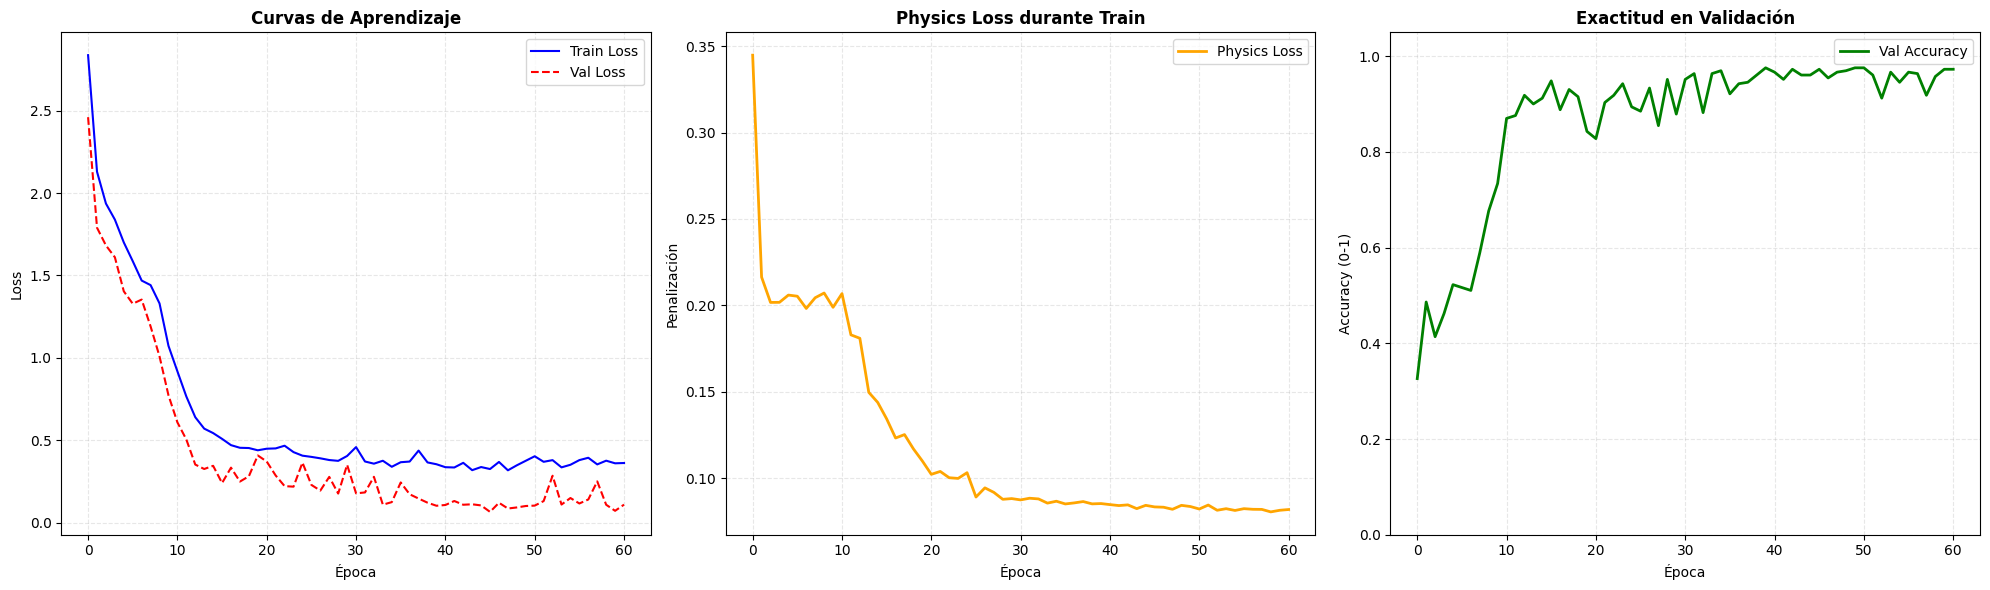

Generando predicciones en Test...


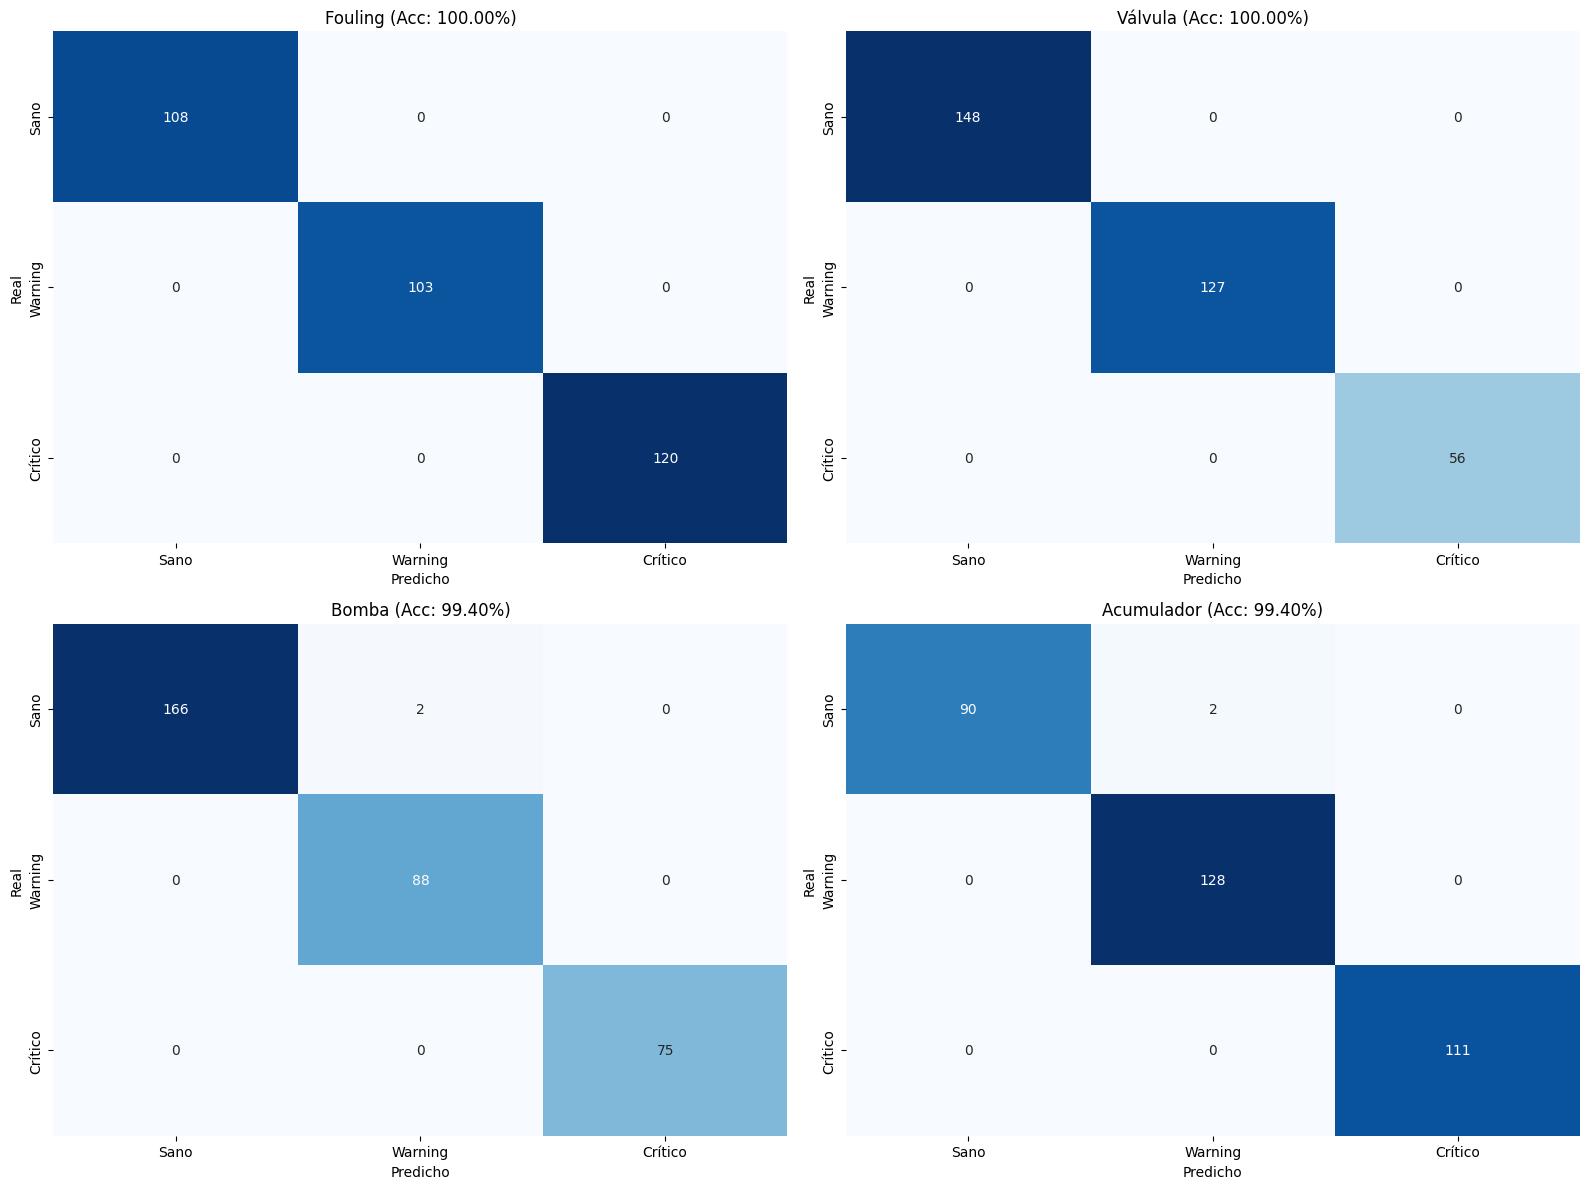

📊 Calculando métricas...

           📊 MÉTRICAS GLOBALES DEL MODELO DNS          
 🔹 Exactitud Global (Subset) :  0.9879
 🔹 Recall Global (Macro)     :  0.9972
 🔹 F1-Score Global (Macro)   :  0.9970

>>> DESGLOSE POR CLASE:


,Componente,Clase,Accuracy,Recall,F1-Score,Support
0,Fouling,Sano,100.00%,100.00%,100.00%,108
1,Fouling,Warning,100.00%,100.00%,100.00%,103
2,Fouling,Crítico,100.00%,100.00%,100.00%,120
3,Válvula,Sano,100.00%,100.00%,100.00%,148
4,Válvula,Warning,100.00%,100.00%,100.00%,127
5,Válvula,Crítico,100.00%,100.00%,100.00%,56
6,Bomba,Sano,99.40%,98.81%,99.40%,168
7,Bomba,Warning,99.40%,100.00%,98.88%,88
8,Bomba,Crítico,99.40%,100.00%,100.00%,75
9,Acumulador,Sano,99.40%,97.83%,98.90%,92


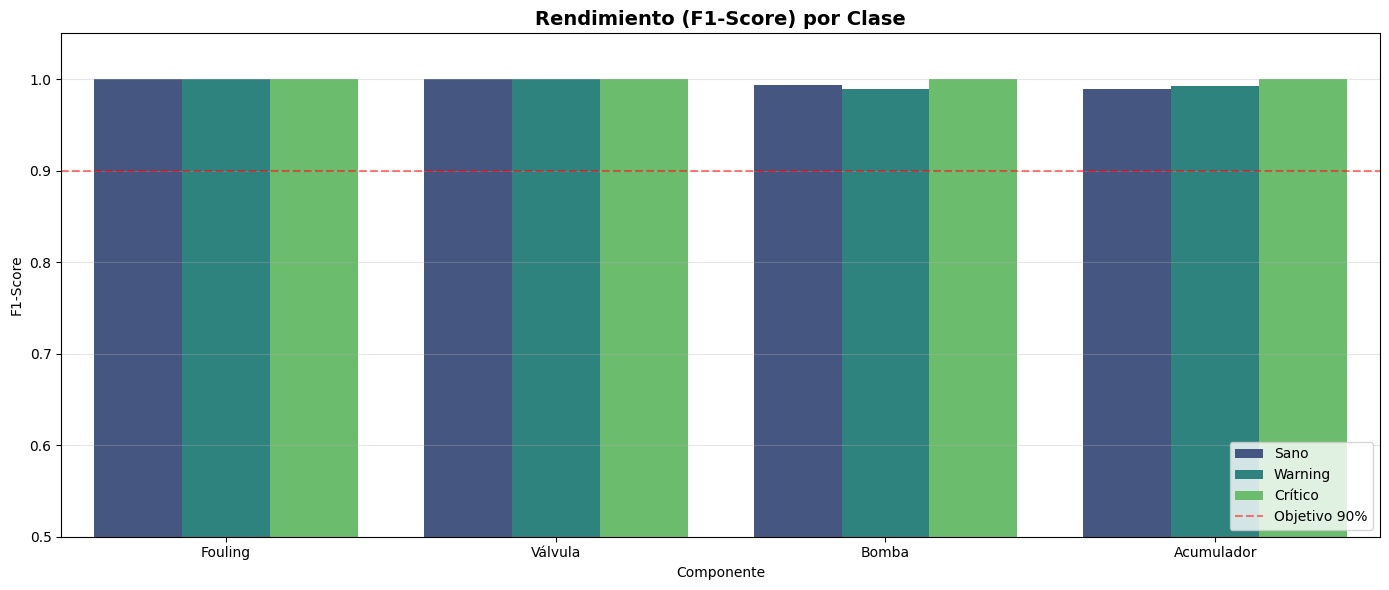

In [80]:
# ==============================================================================
# 1. GRÁFICAS Train vs Val
# ==============================================================================
plt.figure(figsize=(20, 6))

# --- GRÁFICA 1: TRAIN LOSS vs VAL LOSS ---
plt.subplot(1, 3, 1)
plt.plot(history_dns['train_loss'], label='Train Loss', color='blue')
plt.plot(history_dns['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Curvas de Aprendizaje', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# --- GRÁFICA 2: PHYSICS LOSS ---
plt.subplot(1, 3, 2)
plt.plot(history_dns['phys_loss'], label='Physics Loss', color='orange', linewidth=2)
plt.title('Physics Loss durante Train', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Penalización')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# --- GRÁFICA 3: ACCURACY ---
plt.subplot(1, 3, 3)
plt.plot(history_dns['val_acc'], label='Val Accuracy', color='green', linewidth=2)
plt.title('Exactitud en Validación', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Accuracy (0-1)')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. GENERACIÓN DE PREDICCIONES
# ==============================================================================
model_dns.eval()
y_true_list = []
y_pred_list = []

print("Generando predicciones en Test...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.cpu().numpy()

        # Forward
        p_foul, p_valv, p_bomb, p_acum = model_dns(inputs)
        
        # Argmax y apilado
        preds_batch = torch.stack([
            p_foul.argmax(1), p_valv.argmax(1), p_bomb.argmax(1), p_acum.argmax(1)
        ], dim=1).cpu().numpy()

        y_true_list.append(labels)
        y_pred_list.append(preds_batch)

y_true = np.vstack(y_true_list)
y_pred = np.vstack(y_pred_list)
target_names = ['Fouling', 'Válvula', 'Bomba', 'Acumulador']
class_labels = ['Sano', 'Warning', 'Crítico']


# ==============================================================================
# 3. MATRIZ DE CONFUSIÓN
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i in range(4):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[i].set_title(f'{target_names[i]} (Acc: {acc:.2%})')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.tight_layout()
plt.show()


# ==============================================================================
# 4. REPORTE DE MÉTRICAS GLOBALES Y POR CLASE
# ==============================================================================
print("📊 Calculando métricas...")

# MÉTRICAS GLOBALES
subset_accuracy_dns = (y_true == y_pred).all(axis=1).mean()
recalls_macro_dns = []
f1s_macro_dns = []

for i in range(4):
    r_macro = recall_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
    f_macro = f1_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
    recalls_macro_dns.append(r_macro)
    f1s_macro_dns.append(f_macro)

global_macro_recall_dns = np.mean(recalls_macro_dns)
global_macro_f1_dns = np.mean(f1s_macro_dns)

print("\n" + "="*55)
print(" 📊 MÉTRICAS GLOBALES DEL MODELO DNS ".center(55))
print("="*55)
print(f" 🔹 Exactitud Global (Subset) :  {subset_accuracy_dns:.4f}")
print(f" 🔹 Recall Global (Macro)     :  {global_macro_recall_dns:.4f}")
print(f" 🔹 F1-Score Global (Macro)   :  {global_macro_f1_dns:.4f}")
print("="*55 + "\n")

# MÉTRICAS DETALLADAS POR CLASE
metrics_data = []
for i, component in enumerate(target_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true[:, i], y_pred[:, i], labels=[0, 1, 2], zero_division=0
    )
    for cls_idx, cls_name in enumerate(class_labels):
        metrics_data.append({
            'Componente': component,
            'Clase': cls_name,
            'Accuracy': accuracy_score(y_true[:, i], y_pred[:, i]),
            'Recall': recall[cls_idx],
            'F1-Score': f1[cls_idx],
            'Support': support[cls_idx]
        })

df_metrics = pd.DataFrame(metrics_data)

def color_metrics(val):
    if isinstance(val, float):
        if val < 0.8: color = '#ffadad'
        elif val < 0.9: color = '#ffd6a5'
        else: color = '#caffbf'
        return f'background-color: {color}; color: black'
    return ''

print(">>> DESGLOSE POR CLASE:")
display(df_metrics.style.format({
    'Accuracy': '{:.2%}',
    'Recall': '{:.2%}',
    'F1-Score': '{:.2%}'
}).map(color_metrics, subset=['Accuracy', 'Recall', 'F1-Score']))

# GRÁFICA RESUMEN
plt.figure(figsize=(14, 6))
sns.barplot(data=df_metrics, x='Componente', y='F1-Score', hue='Clase', palette='viridis')
plt.title('Rendimiento (F1-Score) por Clase', fontsize=14, fontweight='bold')
plt.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Objetivo 90%')
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **Importancia de variables / XAI**


🧠 CALCULANDO EXPLICABILIDAD FÍSICA (XAI) POR COMPONENTE


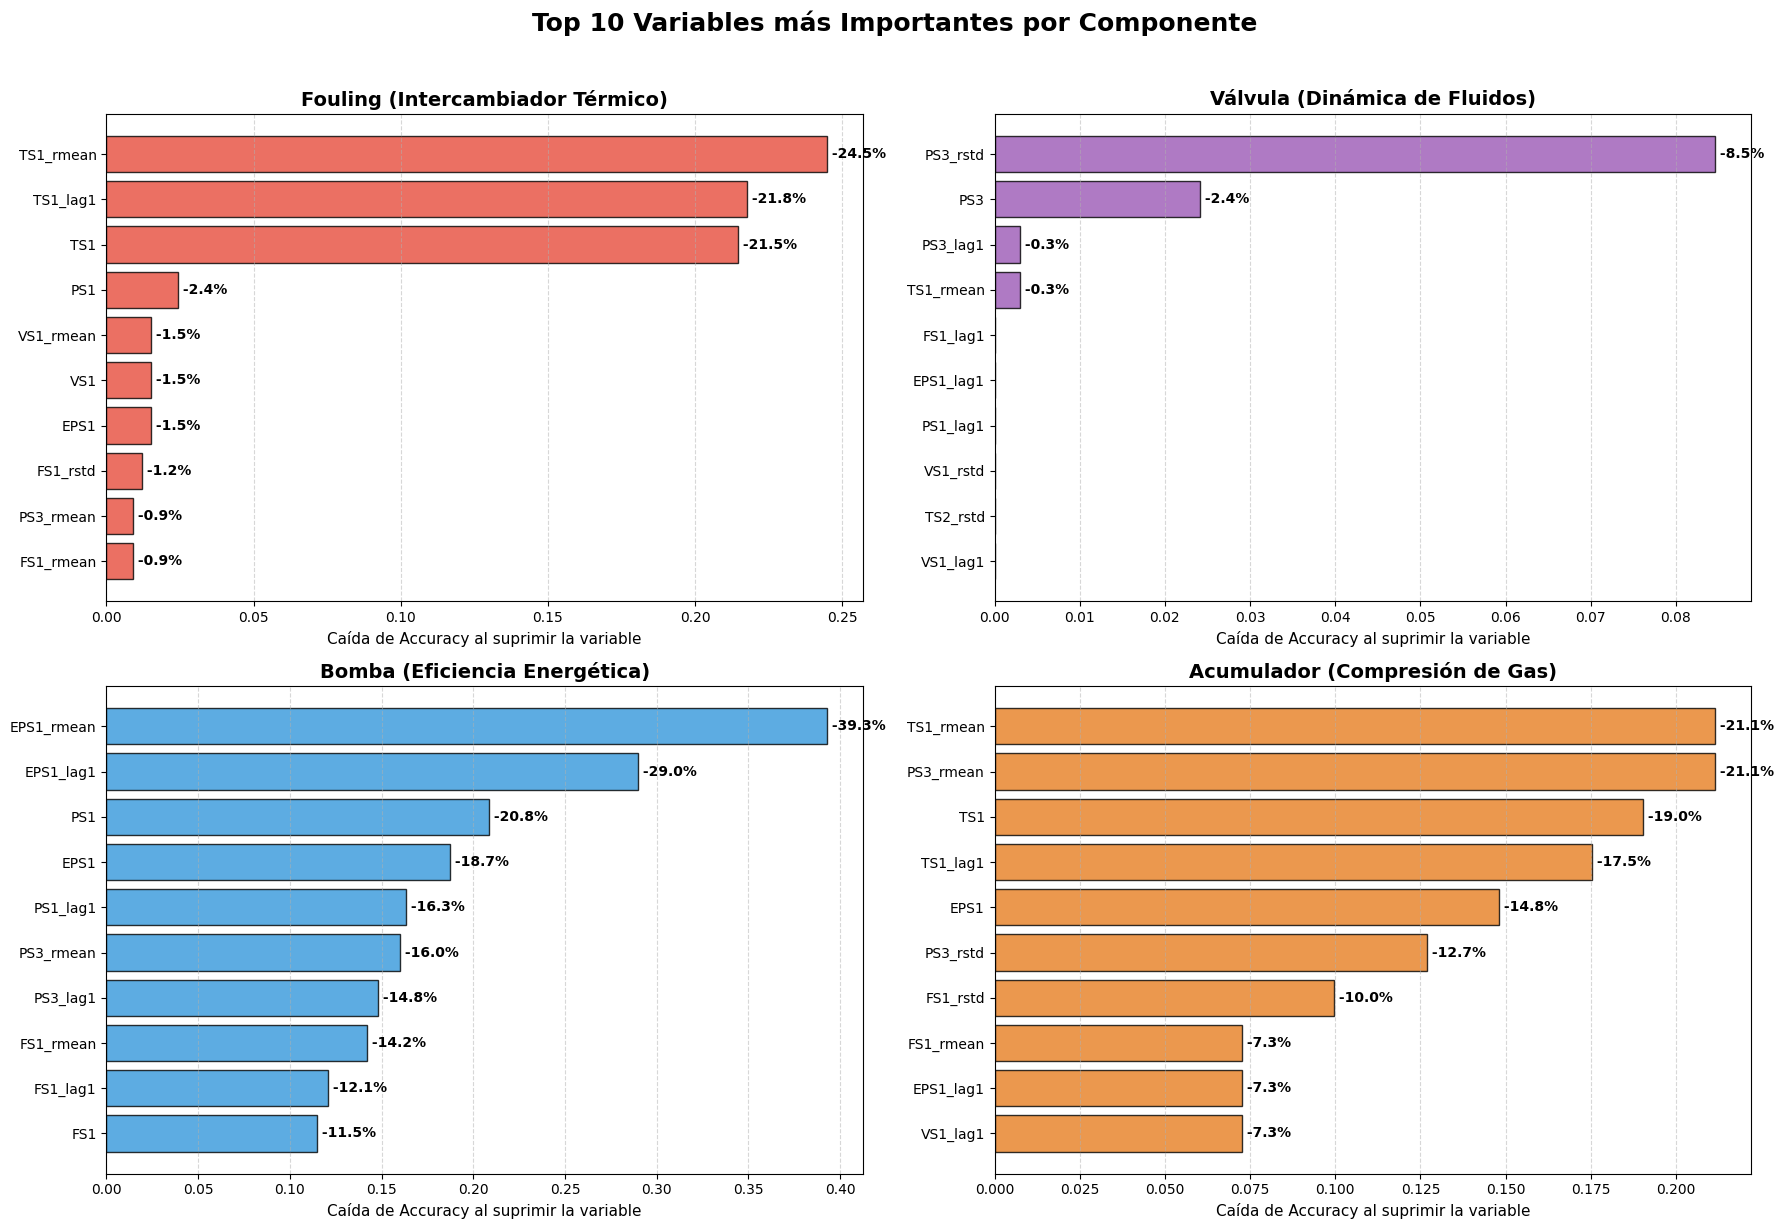

In [81]:
# ==============================================================================
# 5. PERMUTATION FEATURE IMPORTANCE (POR TARGET)
# ==============================================================================
print("\n" + "="*55)
print("🧠 CALCULANDO EXPLICABILIDAD FÍSICA (XAI) POR COMPONENTE")
print("="*55)

def calculate_importance_per_target(model, loader, feature_names, device, seed=42):
    model.eval()
    
    # 1. Recolectar todos los datos de Test
    X_all, y_all = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            X_all.append(inputs)
            y_all.append(labels)
            
    X_all = torch.cat(X_all, dim=0).to(device)
    y_all = torch.cat(y_all, dim=0).to(device)
    
    # 2. Función interna para evaluar Accuracy de cada cabeza por separado
    def eval_targets(X, y):
        correct = np.zeros(4)
        total = X.size(0)
        with torch.no_grad():
            for i in range(0, total, 64):
                inputs = X[i:i+64]
                labels = y[i:i+64]
                preds = model(inputs) # Devuelve 4 tensores
                
                for head_idx in range(4):
                    pred_class = preds[head_idx].argmax(dim=1)
                    correct[head_idx] += (pred_class == labels[:, head_idx]).sum().item()
        return correct / total

    # 3. Accuracy Base (Sin alterar nada)
    base_accs = eval_targets(X_all, y_all)
    
    # 4. Permutación variable a variable
    importances = {0: [], 1: [], 2: [], 3: []}
    torch.manual_seed(seed)
    
    for feat_idx in range(len(feature_names)):
        X_permuted = X_all.clone()
        
        # Barajamos solo el canal correspondiente a la variable actual a lo largo del batch
        idx = torch.randperm(X_all.size(0))
        X_permuted[:, feat_idx, :] = X_permuted[idx, feat_idx, :]
        
        # Medimos el impacto
        perm_accs = eval_targets(X_permuted, y_all)
        
        # Guardamos la caída (Drop) en Accuracy para cada cabeza
        for head_idx in range(4):
            drop = base_accs[head_idx] - perm_accs[head_idx]
            importances[head_idx].append(drop)
            
    return importances

# Ejecutamos el cálculo
importances_dict = calculate_importance_per_target(model_dns, test_loader, feature_cols, device)

# ==============================================================================
# VISUALIZACIÓN DE LA IMPORTANCIA DE VARIABLES (SUBPLOTS)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle('Top 10 Variables más Importantes por Componente', fontsize=18, fontweight='bold', y=1.02)

colores = ['#e74c3c', '#9b59b6', '#3498db', '#e67e22'] # Rojo (Termo), Morado, Azul (Bomba), Naranja
nombres_explicativos = [
    'Fouling (Intercambiador Térmico)', 
    'Válvula (Dinámica de Fluidos)', 
    'Bomba (Eficiencia Energética)', 
    'Acumulador (Compresión de Gas)'
]

for i in range(4):
    # Obtener el array de importancias para el componente 'i'
    imp_array = np.array(importances_dict[i])
    
    # Extraer los índices de las 10 variables con mayor impacto
    top_10_idx = np.argsort(imp_array)[-10:]
    top_10_vals = imp_array[top_10_idx]
    top_10_names = [feature_cols[j] for j in top_10_idx]
    
    # Graficar
    ax = axes[i]
    bars = ax.barh(top_10_names, top_10_vals, color=colores[i], edgecolor='black', alpha=0.8)
    ax.set_title(nombres_explicativos[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Caída de Accuracy al suprimir la variable', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Añadir el porcentaje exacto en la barra
    for bar in bars:
        width = bar.get_width()
        if width > 0:
            ax.text(width, bar.get_y() + bar.get_height()/2, f' -{width:.1%}', 
                    va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Lo que debería ver el modelo:**

* **Fouling** (Enfriador/Placas): Debería liderar el ranking las temperaturas (TS1, TS2). Si la variable más importante aquí fuera la vibración (VS1), el modelo está haciendo trampas o sobreajustando.
* **Bomba**: La Ley de Conservación de Energía dictamina que la potencia eléctrica y la presión deben liderar. Debería verse a EPS1 (Potencia), PS1 (Presión de salida) y FS1 (Caudal).
* **Válvula**: Las válvulas generan caídas de presión y fluctuaciones. Debería haber variables de derivadas o varianza en el top, como PS1_rstd (Inestabilidad en la presión) o FS1_rstd (Inestabilidad en el caudal).
* **Acumulador**: Al perder presión de nitrógeno, el circuito se vuelve menos "elástico". La presión PS1 o la presión secundaria PS3 deberían dominar este gráfico.

## **INFERENCIA (PREDICT)**

In [82]:
def aplicar_gemelo_digital(cycle_df_raw, ts1_mean_train):
    """
    Aplica estrictamente la misma traslación térmica que en la fase de entrenamiento.
    """
    cols_sensores_base = ['PS1', 'PS3', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1']
    df_temp = cycle_df_raw.copy()
    
    if 'Time_Segundos' not in df_temp.columns:
        df_temp['Time_Segundos'] = df_temp['Time'].round(1)

    df_10hz = df_temp.groupby('Time_Segundos')[cols_sensores_base].mean().reset_index()
    df_thermo = df_10hz.copy()
    
    # TRASLACIÓN EXACTA (Sin alterar el Delta T)
    offset_temperatura = 65.0 - ts1_mean_train
    df_thermo['TS1'] = df_thermo['TS1'] + offset_temperatura
    df_thermo['TS2'] = df_thermo['TS2'] + offset_temperatura
    
    return df_thermo

def inferencia_produccion(df_leche, model, scaler, feature_cols, device):
    """
    Pipeline puro de Machine Learning. 
    Espera datos con variables termodinámicas ya correctas (Leche).
    """
    cols_sensores_base = ['PS1', 'PS3', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1']
    df_thermo = df_leche.sort_values('Time_Segundos').copy()
    
    # 1. FEATURE ENGINEERING
    X_sensores = df_thermo[cols_sensores_base]
    rmean = X_sensores.rolling(5, min_periods=1).mean().add_suffix('_rmean')
    rstd = X_sensores.rolling(5, min_periods=1).std().fillna(0).add_suffix('_rstd')
    lag = X_sensores.shift(1).bfill().add_suffix('_lag1') 
    
    df_processed = pd.concat([df_thermo, rmean, rstd, lag], axis=1)

    # 2. ORDENACIÓN Y EXTRACCIÓN
    try:
        df_processed = df_processed[feature_cols] 
        X_raw = df_processed.values 
    except KeyError as e:
        print(f"❌ Error al emparejar características. Faltan: {e}")
        return None

    # 3. ESCALADO
    X_scaled = scaler.transform(X_raw)

    # 4. CONSTRUCCIÓN DEL TENSOR
    target_len = 600
    if X_scaled.shape[0] < target_len:
        pad = np.zeros((target_len - X_scaled.shape[0], X_scaled.shape[1]))
        X_ready = np.vstack([X_scaled, pad])
    elif X_scaled.shape[0] > target_len:
        X_ready = X_scaled[:target_len, :]
    else:
        X_ready = X_scaled
        
    input_tensor = torch.tensor(X_ready, dtype=torch.float32).unsqueeze(0).permute(0, 2, 1).to(device)

    # 5. PREDICCIÓN
    model.eval()
    with torch.no_grad():
        p_foul, p_valv, p_bomb, p_acum = model(input_tensor)
        
        probs = [torch.softmax(p, dim=1) for p in [p_foul, p_valv, p_bomb, p_acum]]
        preds = [p.argmax(1).item() for p in probs]
        confidences = [p.max(1).values.item() for p in probs]

    # 6. DASHBOARD
    components = ['Enfriador (Fouling)', 'Válvula (Switch)', 'Bomba (Leakage)', 'Acumulador (Gas)']
    states = ['🟢 SANO', '🟡 WARNING', '🔴 CRÍTICO']
    
    print("\n")
    print(f"╔{'═'*65}╗")
    print(f"║   REPORTE TÉCNICO DE MANTENIMIENTO PREDICTIVO                 ║")
    print(f"╠{'═'*65}╣")
    print(f"║ {'COMPONENTE':<22} | {'ESTADO DETECTADO':<16} | {'CONFIANZA':<10}    ║")
    print(f"╟{'─'*65}╢")
    
    for i, comp in enumerate(components):
        print(f"║ {comp:<22} | {states[preds[i]]:<16} | {confidences[i]:.2%}       ║")
        
    print(f"╚{'═'*65}╝\n")
    
    return {"predicciones": preds, "confianzas": confidences}

# ==============================================================================
# EJECUCIÓN Y VERIFICACIÓN (FUERA DE LA FUNCIÓN)
# ==============================================================================

# 1. Seleccionamos el ciclo de test
CYCLE_ID_TEST = test_cycles[3] 
df_plc_simulado = df_raw[df_raw['Cycle_ID'] == CYCLE_ID_TEST].copy()

# 2. Extraemos la REALIDAD (Ground Truth) directamente del dataset original
targets_verif = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador']
etiquetas_reales = df_raw[df_raw['Cycle_ID'] == CYCLE_ID_TEST][targets_verif].iloc[0].values.astype(int)

# 3. Tratamos la temperatura
df_leche_simulada = aplicar_gemelo_digital(df_plc_simulado, TS1_MEAN_TRAIN)

# 4. Inferencia pura
resultados = inferencia_produccion(df_leche_simulada, model_dns, scaler, feature_cols, device)

# 5. Imprimir el estado real y la comparativa final
if resultados is not None:
    states = ['🟢 SANO', '🟡 WARNING', '🔴 CRÍTICO']
    components = ['Enfriador (Fouling)', 'Válvula (Switch)', 'Bomba (Leakage)', 'Acumulador (Gas)']

    print(f"🔍 VERIFICACIÓN DE LA PREDICCIÓN (Ciclo {CYCLE_ID_TEST})")
    print(f"┌{'─'*63}┐")
    print(f"│ {'COMPONENTE':<22} │ {'PREDICCIÓN MODELO':<16} │ {'REALIDAD':<15} │")
    print(f"├{'─'*63}┤")

    todo_correcto = True
    for i, comp in enumerate(components):
        pred_txt = states[resultados['predicciones'][i]]
        real_txt = states[etiquetas_reales[i]]
        
        marca = "✅" if resultados['predicciones'][i] == etiquetas_reales[i] else "❌"
        if marca == "❌": todo_correcto = False
            
        print(f"│ {comp:<22} │ {pred_txt:<16} │ {real_txt:<12} {marca:<2}│")
    print(f"└{'─'*63}┘")

    if todo_correcto:
        print("✨ El modelo diagnosticó el ciclo a la perfección.")
    else:
        print("⚠️ El modelo cometió algún error en este ciclo.")



╔═════════════════════════════════════════════════════════════════╗
║   REPORTE TÉCNICO DE MANTENIMIENTO PREDICTIVO                 ║
╠═════════════════════════════════════════════════════════════════╣
║ COMPONENTE             | ESTADO DETECTADO | CONFIANZA     ║
╟─────────────────────────────────────────────────────────────────╢
║ Enfriador (Fouling)    | 🔴 CRÍTICO        | 99.98%       ║
║ Válvula (Switch)       | 🟢 SANO           | 100.00%       ║
║ Bomba (Leakage)        | 🟢 SANO           | 100.00%       ║
║ Acumulador (Gas)       | 🟢 SANO           | 99.95%       ║
╚═════════════════════════════════════════════════════════════════╝

🔍 VERIFICACIÓN DE LA PREDICCIÓN (Ciclo 76)
┌───────────────────────────────────────────────────────────────┐
│ COMPONENTE             │ PREDICCIÓN MODELO │ REALIDAD        │
├───────────────────────────────────────────────────────────────┤
│ Enfriador (Fouling)    │ 🔴 CRÍTICO        │ 🔴 CRÍTICO    ✅ │
│ Válvula (Switch)       │ 🟢 SANO           │ 🟢 